Importing Libraries for project implementation.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
import seaborn as sns
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Dense, Flatten
from tensorflow.keras.utils import to_categorical

#Loading dataset as csv for Images

We will load the dataset and inspect its structure to understand the features and labels. You can download this dataset from here.

1. The dataset contains 42,000 rows where each row represents an image.

2. The first column (label) indicates the digit (0-9) and the remaining columns represent pixel values of the image.
3. We separate these into X (pixel values) and y (labels).
4. X has 42,000 samples with 784 features (28x28 pixels) and y has 42,000 labels.

In [ ]:
train_data = pd.read_csv('...\Handwritten-Digit-Classifier-ML\dataset\Train.csv')
print("Shape of train_data:", train_data.shape)


X = train_data.iloc[:, 1:]
y = train_data.iloc[:, 0]

print("Shape of X after separating features:", X.shape)

Shape of train_data: (42000, 785)
Shape of X after separating features: (42000, 784)


# Preprocess data

Raw data often needs cleaning and formatting before it can be fed into a neural network. Let’s preprocess the data to make it ready for training.


1.   First ensuring X is in the correct format (Pandas DataFrame).
2.  Then converting all pixel values to numeric format and replace any missing values with 0.
3.  Next we normalize the pixel values to the range [0, 1] by dividing them by 255.0 ( Pixel intensity ). This helps the model learn faster.

4.  Finally we reshape the data to include a channel dimension making it compatible with neural networks.










#Notes:



*   iloc means index-based selection
*   iloc[row_index, column_index]




In [ ]:
if not isinstance(X, pd.DataFrame):
    X = pd.DataFrame(X)
X = X.apply(pd.to_numeric, errors='coerce')
X = X.fillna(0)
X = X.values / 255.0  #Normalizing data
X = X.reshape(-1, 28, 28, 1)
print("Shape of X after reshaping:", X.shape)

Shape of X after reshaping: (42000, 28, 28, 1)


#One-Hot Encode the Labels

Neural networks need labels in one‑hot format.


In [ ]:
y = to_categorical(y, num_classes=10)
print("Shape of y after one-hot encoding:", y.shape)

Shape of y after one-hot encoding: (42000, 10)


# Spliting the Data

In [ ]:
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)
print("X_train shape:", X_train.shape)

X_train shape: (33600, 28, 28, 1)


#Build the Neural Network Model

Defining a simple feedforward neural network with three layers:

*   A Flatten layer converts the 28x28 image into a single vector of length 784.

*   Two hidden layers with 128 and 64 neurons use the ReLU activation function to introduce non-linearity.

*  An output layer with 10 neurons uses the softmax activation function to predict probabilities for each digit (0-9).

*   compiling the model with the Adam optimizer, categorical cross-entropy loss, and accuracy as the evaluation metric.

---





In [ ]:
import keras
from keras import layers
from keras import ops


In [ ]:
model = Sequential([
    Input(shape=(28, 28, 1)),
    Flatten(),
    Dense(128, activation='relu'),
    Dense(64, activation='relu'),
    Dense(10, activation='softmax')
])
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_1 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,386 (427.29 KB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)

#Training the model

In [ ]:
history = model.fit(X_train, y_train, epochs=10, batch_size=32, validation_data=(X_val, y_val))

Epoch 1/10
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 11s 8ms/step - accuracy: 0.9111 - loss: 0.3006 - val_accuracy: 0.9496 - val_loss: 0.1722
Epoch 2/10
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 11s 10ms/step - accuracy: 0.9613 - loss: 0.1305 - val_accuracy: 0.9573 - val_loss: 0.1444
Epoch 3/10
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 8s 7ms/step - accuracy: 0.9722 - loss: 0.0886 - val_accuracy: 0.9663 - val_loss: 0.1137
Epoch 4/10
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 7s 7ms/step - accuracy: 0.9786 - loss: 0.0666 - val_accuracy: 0.9724 - val_loss: 0.0975
Epoch 5/10
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - accuracy: 0.9848 - loss: 0.0487 - val_accuracy: 0.9680 - val_loss: 0.1090
Epoch 6/10
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 9s 9ms/step - accuracy: 0.9874 - loss: 0.0398 - val_accuracy: 0.9638 - val_loss: 0.1273
Epoch 7/10
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - accuracy: 0.9889 - loss: 0.0326 - val_accuracy: 0.9690 - val_loss: 0.1185
Epoch 8/10
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 8s 8ms/step - accuracy: 0.9928 - loss: 0.0229

#Evaluating the Model

263/263 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9698 - loss: 0.1244
Validation Accuracy: 96.98%


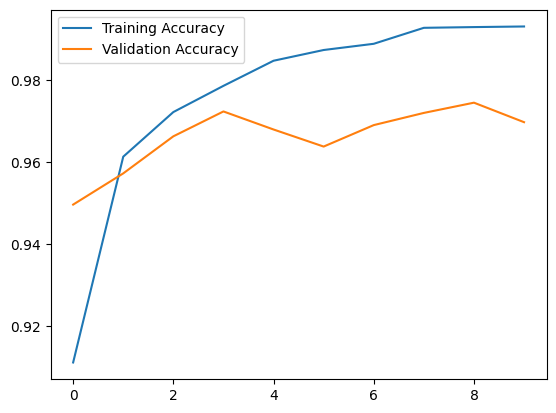

In [ ]:
val_loss, val_accuracy = model.evaluate(X_val, y_val)
print(f"Validation Accuracy: {val_accuracy * 100:.2f}%")
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.legend()
plt.show()


# Recall to check false positivs, generalize ability- validation techniques--(k-fold validation)

#Making Predictions

175/175 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


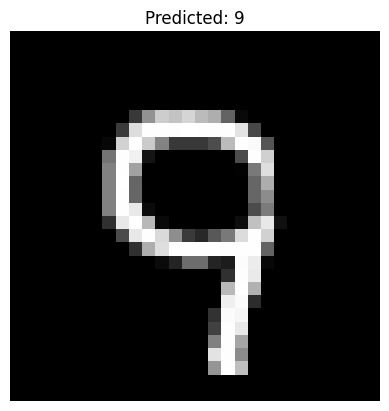

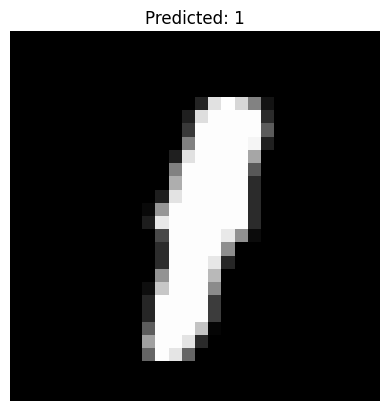

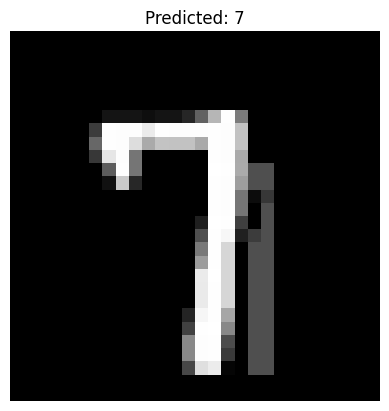

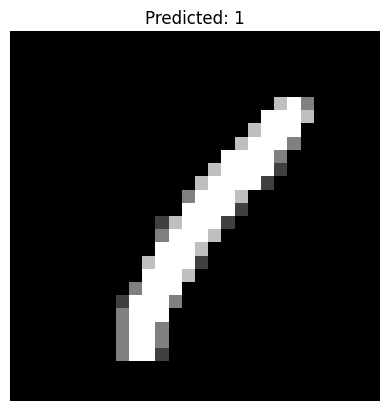

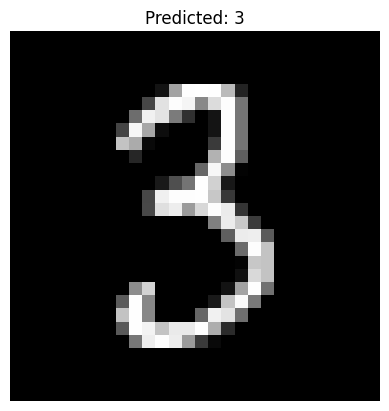

In [ ]:
test_data = pd.read_csv('...\Handwritten-Digit-Classifier-ML\dataset\test.csv')
X_test = test_data.values / 255.0
X_test = X_test.reshape(-1, 28, 28, 1)
predictions = model.predict(X_test)
predicted_labels = np.argmax(predictions, axis=1)
for i in range(5):
    plt.imshow(X_test[i].reshape(28, 28), cmap='gray')
    plt.title(f"Predicted: {predicted_labels[i]}")
    plt.axis('off')
    plt.show()